<h1 style="font-size: 1.6rem; font-weight: bold">ITO 5221: Intelligent Image and Video Analysis</h1>
<h1 style="font-size: 1.6rem; font-weight: bold">Module 4.2: Object Detection</h1>
<p style="margin-top: 5px; margin-bottom: 5px;">Monash University Australia</p>
<p style="margin-top: 5px; margin-bottom: 5px;">Jupyter Notebook by: Tristan Sim Yook Min</p>
References: Information Source from Monash Faculty of Information Technology

---

### **What is Object Detection**

In the previous topic, four types of object recognition were introduced. Here we focus on the third type **object detection**.

| Type | Task |
|---|---|
| Semantic Segmentation | Assign a class label to every pixel |
| Classification & Localisation | Predict the class and location of a single object |
| **Object Detection** | **Detect multiple objects with their classes and bounding boxes** |
| Instance Segmentation | Pixel-level segmentation with class and location for multiple objects |

<br>

#### **How Object Detection Differs from Classification**

In a standard classification problem, the model predicts a single label for the entire image. In object detection, the model must predict:

1. **The class** (label) of each object, exmaple, "person", "motorbike"
2. **The bounding box** (bbox) the rectangular region that locates each object in the image

For a given input image, the desired output is a set of labelled bounding boxes, one for each detected object.

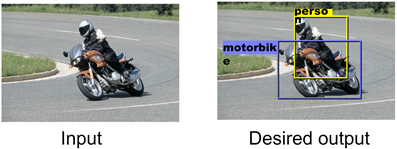

*Source: Object detection: motorbike example (2022) courtesy of the Faculty of Information Technology*

<br>

#### **Evaluating Object Detection**

In classification, **accuracy** is the standard evaluation metric. Object detection requires more nuanced metrics because predictions involve both a class and a spatial location.

Consider an example where a model is given a test image and predicts three objects, each with a **confidence score** indicating how certain the model is about each detection. These predictions are then compared against the **ground truth** (the actual objects and their locations).

The evaluation process works as follows:


1. **Sort** all predictions by confidence (highest first)
2. **Compare** each prediction against the ground truth based on spatial overlap
3. **Classify** each prediction:

| Result | Condition |
|---|---|
| **True Positive (TP)** | Correct class and high overlap with a ground truth box |
| **False Positive (FP)** | No overlap, low overlap, or a duplicate detection of an already-matched object |

These counts form the basis for computing precision, recall, and other detection metrics.


### **Precision and Recall**

At a given confidence threshold $t$, we can compute two key metrics:

#### **Precision**

Of all the detections the model made at threshold $t$, how many were actually correct?

$$\text{precision@}t = \frac{\#\text{true positives@}t}{\#\text{true positives@}t + \#\text{false positives@}t}$$

Think of it as: out of everything the model **claimed** to detect, what fraction was right?

- ✔ = true positive (correct detection)
- ✘ = false positive (incorrect detection)

#### **Recall**

Of all the actual objects in the image, how many did the model successfully detect?

$$\text{recall@}t = \frac{\#\text{true positives@}t}{\#\text{ground truth objects}}$$

Think of it as: out of everything that **actually exists**, what fraction did the model find?

<br>

#### **Precision vs. Recall Trade-off**

| High Threshold $t$ | Low Threshold $t$ |
|---|---|
| Fewer detections, but most are correct | More detections, but more false positives |
| **High precision, low recall** | **Low precision, high recall** |

There is always a trade-off increasing one typically decreases the other. The goal is to find a balance depending on the application.

---

### **General Process of Object Detection**

The general process of object detection can be divided into four steps:

1. **Specify the object model**
2. **Generate hypotheses**
3. **Score hypotheses**
4. **Resolve detections**

<br>

#### **Step 1:  Specify the Object Model**

The first step is to decide how to represent the object. There are several approaches:

| Representation | Description |
|---|---|
| Statistical template | A fixed pattern learned from data |
| Articulated parts | Models the object as a collection of connected parts |
| Hybrid template/parts model | Combines a global template with local part-based modelling |
| 3D-ish model | Incorporates rough 3D structure or viewpoint information |

<br>

#### **Step 2: Generate Hypotheses**

Once we have chosen an object representation, we need to propose candidate locations where the object might be. Methods include:

| Method | Approach |
|---|---|
| Sliding window | Test a patch at every location and scale across the image |
| Voting from patches/keypoints | Let local features vote for possible object locations |
| Region-based proposal | Generate candidate regions likely to contain objects |

<br>

#### **Step 3:  Score Hypotheses**

Each generated hypothesis is then evaluated. **Gradient-based approaches** can be used to extract features from each candidate region, and various **classifiers** are applied to produce a confidence score for each proposal.

<br>

#### **Step 4: Resolve Detections**

The previous steps typically produce many overlapping or duplicated proposals for the same object. **Non-maximum suppression (NMS)** is applied to remove these duplicates — keeping only the highest-scoring detection for each object and discarding proposals that overlap too heavily with it.

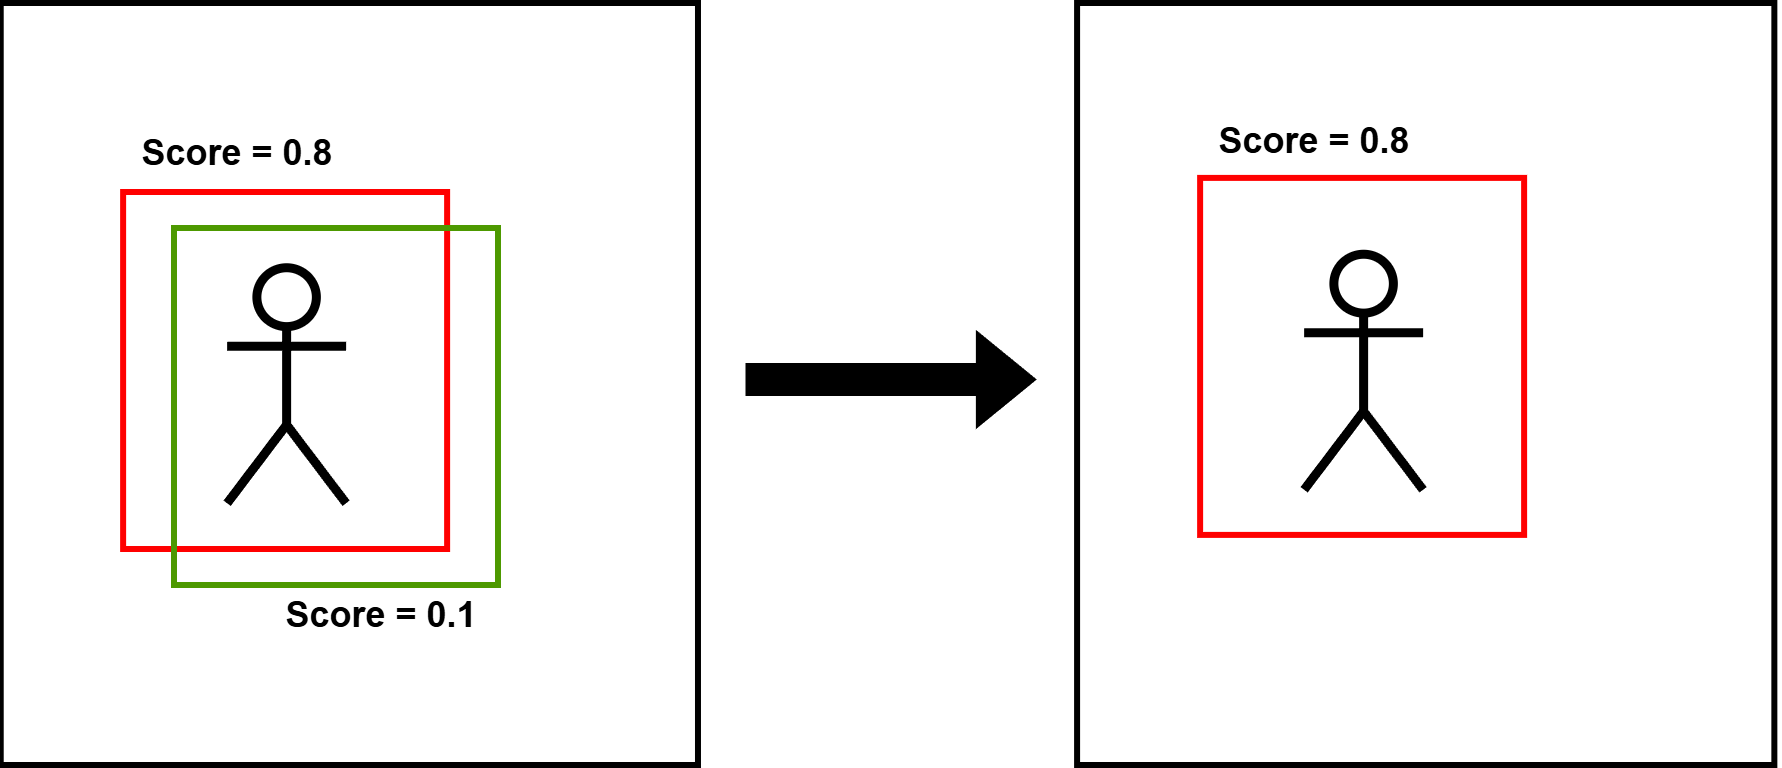

---

### **Region Proposals**

In deep learning-based object detection, **region proposals** are used as an alternative to sliding window search. A sliding window exhaustively tests every possible location and scale, producing a very large number of candidate regions. Region proposal methods instead focus only on **meaningful regions**, significantly reducing the number of proposals to evaluate.

#### **Advantages of Region Proposals**

| Advantage | Explanation |
|---|---|
| Slower but more powerful features | Fewer proposals means we can afford to use richer, more expensive classifiers |
| Low-level perceptual cues | Takes advantage of colour, texture, and edge information to identify promising regions |
| Category-independent | The proposal mechanism does not need to know what object it is looking for |
| Trainable | The proposal generation process itself can be learned from data |

<br>

#### **Selective Search**

One of the most influential region proposal methods is **Selective Search**. It works using **hierarchical segmentation**:

1. Start with many small **superpixels**
2. Iteratively **merge** neighbouring regions based on diverse cues (colour, texture, size, shape)
3. Proposals are generated from the merged regions at every level of the hierarchy

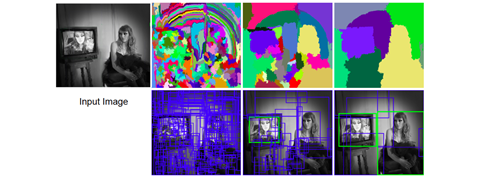

*Source: Selective search (2011) <https://bit.ly/3qZAbm>*

<br>

#### **Edge Boxes**

Another proposal method is **Edge Boxes**, which scores candidate regions based on edge information:

$$\text{Box score} = \text{edges inside the box} - \text{edges overlapping the box boundary}$$

| Property | Detail |
|---|---|
| Edge detection | Uses a **trained edge detector** |
| Efficiency | Uses efficient data structures (including **integral images**) for fast evaluation |
| Recall | Achieves **75% recall with only 800 boxes** (vs. 1400 for Selective Search) |
| Speed | Approximately **40× faster** than Selective Search |

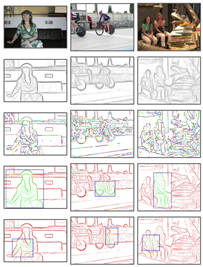

*Source: Edge boxes (2014) <https://bit.ly/3wZ9a79>*

---

### **Region CNN (R-CNN)**

**R-CNN** is one of the most important foundational works in object detection. The pipeline consists of three main stages:

1. **Generate proposals:** Use Selective Search to produce candidate regions
2. **Extract features:** Resize each region to a fixed size and feed it through a pre-trained classification neural network to obtain a feature representation
3. **Classify:** Use a **Support Vector Machine (SVM)** to predict the class label for each region

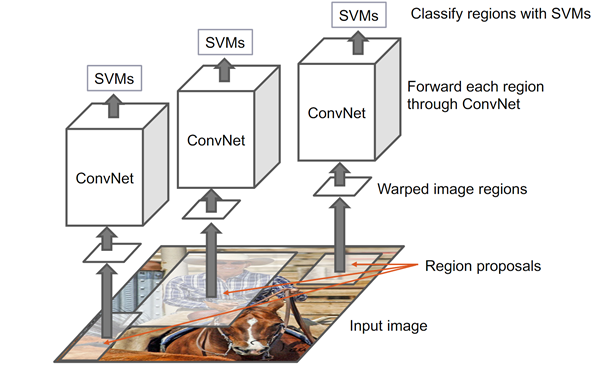

*Source: R-CNN process view 1 (2014) <https://bit.ly/3K1VxaS>*

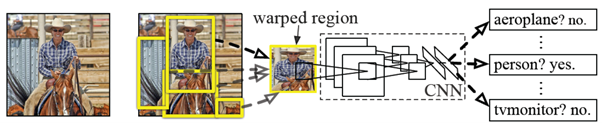

*R-CNN process view 2 (2014) <https://bit.ly/3K1VxaS>*

<br>

#### **Key Features of R-CNN**

| Component | Detail |
|---|---|
| Region proposals | ~2000 proposals generated via Selective Search |
| Network | AlexNet pre-trained on ImageNet (1000 classes), fine-tuned on PASCAL VOC (21 classes) |
| Final detector | Warp each proposal region, extract $\text{fc7}$ activations (4096-d), classify with a linear SVM |
| Box refinement | Bounding box regression to adjust predicted box locations |
| Performance | **53.7% mAP** on PASCAL 2010 (vs. 35.1% for Selective Search, 33.4% for DPM) |

<br>

#### **Pros and Cons of R-CNN**

| Pros | Cons |
|---|---|
| Accurate compared to prior methods | Ad hoc training — three separate objectives: softmax (log loss) for fine-tuning, linear SVM (hinge loss) for classification, least squares for bounding box regression |
| Any deep architecture can be directly plugged in | Training is slow (~84 hours) and requires a lot of disk space |
| | Requires **2000 CNN forward passes per image** |
| | Inference is slow — ~47 seconds per image with VGG16 |

---

### **Fast R-CNN and Faster R-CNN**

#### **Fast R-CNN**

Fast R-CNN was introduced to address the speed limitations of R-CNN. The key difference lies in **where** the CNN is applied:

| | R-CNN | Fast R-CNN |
|---|---|---|
| CNN applied to | Region proposals cropped from the **original image** (high resolution) | Region proposals extracted from the **feature map** (much lower resolution) |
| Speed implication | Slow — full CNN pass for each of ~2000 proposals | Fast — single CNN pass, then extract regions from the shared feature map |

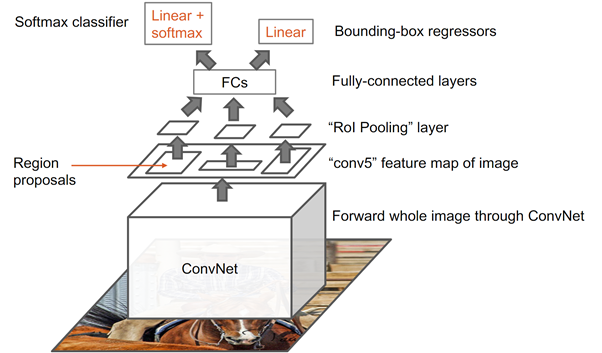

*Source: Fast R-CNN view 1 (2015) <https://bit.ly/3LFaGiG>*

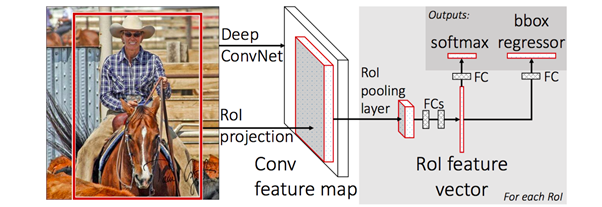

*Fast R-CNN view 2 (2015) <https://bit.ly/3LFaGiG>*

<br>

**How Fast R-CNN works:**

1. Pass the entire image through a CNN to produce a **shared feature map**
2. For each region proposal, use a **RoI (Region of Interest) Pooling** layer to extract and resize the corresponding portion of the feature map to a fixed size
3. Feed the pooled features into **fully connected layers** to produce both a **classification result** and a **bounding box location**

**Training** is also simplified. Instead of three separate objectives (as in R-CNN), Fast R-CNN combines two losses into a single end-to-end training process:

$$\mathcal{L} = \mathcal{L}_{\text{cls}} (\text{log loss}) + \mathcal{L}_{\text{reg}} (\text{smooth } L_1 \text{ loss})$$

| Metric | R-CNN | Fast R-CNN | Improvement |
|---|---|---|---|
| Training speed | Baseline | **8.8× faster** | Simpler, unified training |
| Inference speed | Baseline | **146× faster** | Shared feature computation |
| mAP | Lower | Slightly higher | Better overall accuracy |

<br>

#### **Faster R-CNN**

Released in 2015, Faster R-CNN replaces the external Selective Search step with a learned **Region Proposal Network (RPN)** that generates proposals directly from the feature map.

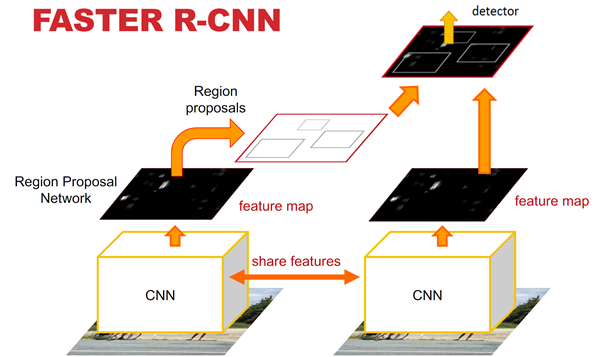

*Source: Faster R-CN (2016) <https://bit.ly/3DBzchT>*

**How the RPN works:**

1. Slide a small window over the CNN feature map
2. At each position, predict **object vs. no object**
3. Regress **bounding box coordinates** relative to a set of **anchors** (predefined reference boxes)

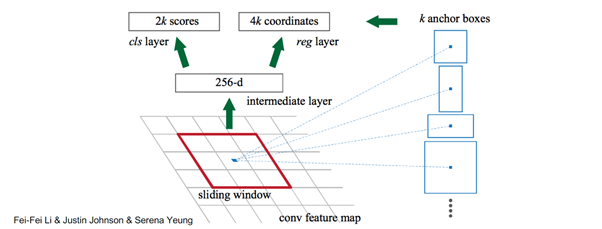

*Source: Faster R-CNN process (2016) <https://bit.ly/3DBzchT>*

The anchors cover multiple combinations:

$$\text{Anchors} = 3 \text{ scales} \times 3 \text{ aspect ratios} = 9 \text{ anchors per location}$$

| Metric | Fast R-CNN | Faster R-CNN |
|---|---|---|
| Proposal method | Selective Search (external) | Region Proposal Network (learned) |
| Inference speed | Baseline | **~10× faster** |

By integrating proposal generation into the network itself, Faster R-CNN achieves a fully end-to-end trainable object detection pipeline.

---

### **YOLO and SSD**

#### **YOLO (You Only Look Once)**

Released in 2016, **YOLO** takes a fundamentally different approach to object detection — instead of generating proposals and classifying them separately, it frames detection as a single regression problem.

**How YOLO works:**

1. Take convolutional feature maps at $7 \times 7$ resolution
2. Add two fully connected layers to predict, at each spatial location:
   - A **score for each class**
   - **2 bounding boxes** with confidence values
3. The output tensor is $7 \times 7 \times 30$ (for PASCAL VOC)

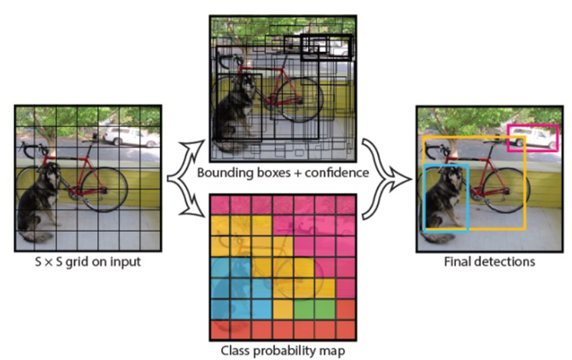

*Source: YOLO object detector (2016) <https://bit.ly/3jge7A9>*

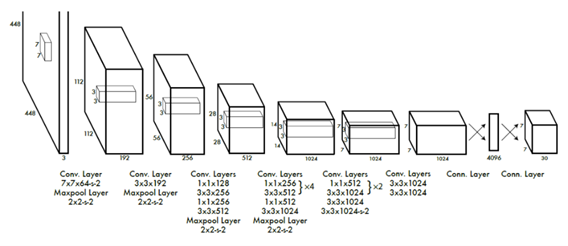

*Source: YOLO object detector process (2016) <https://bit.ly/3jge7A9>*

| Metric | Faster R-CNN | YOLO |
|---|---|---|
| Speed | 7–18 FPS | **45–155 FPS** (~7× faster) |
| Accuracy | Higher recall, better localisation | Some loss in recall and localisation |

<br>

#### **YOLOv2 (2017)**

YOLOv2 introduced several improvements over the original:

| Improvement | Effect |
|---|---|
| Batch normalisation | Stabilises training and improves convergence |
| Higher resolution pre-training | Pre-trains the backbone on higher resolution ImageNet images |
| Anchor boxes | Adopts and improves the anchor box concept from Faster R-CNN |
| Multi-resolution training | Trains at multiple input resolutions for robustness |

The result is a model that achieves **very good accuracy** while remaining **very fast**.

<br>

#### **SSD (Single Shot Detector)**

**SSD** is another single-pass detection method. What makes it distinctive is that it performs classification across **multiple hidden layers** at different scales, generating a total of **7308 detection outputs**. Non-maximum suppression is then applied to resolve duplicates and produce the final detections.

| Property | Detail |
|---|---|
| Detection outputs | 7308 candidates from multiple feature map scales |
| Post-processing | Non-maximum suppression to remove duplicates |
| Performance | Both fast and accurate, competitive with YOLO |

